In [1]:
import cv2
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p

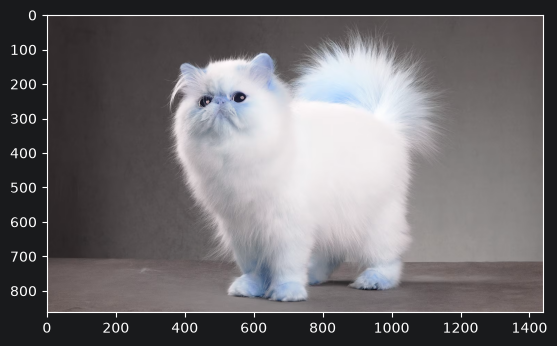

In [2]:
IMG_PATH = p.IMAGE_ASSETS / "cat1.png"
img = cv2.imread(IMG_PATH)

plt.figure()
plt.imshow(img)

# doubleclick drawing

In [3]:
def draw_circle(event, x, y, flags, param):
    img = param

    if event == cv2.EVENT_LBUTTONDBLCLK:
        cv2.circle(img=img,
                   center=(x, y),
                   radius=5,
                   color=(150, 225, 150),
                   thickness=-1,
                   lineType=cv2.LINE_AA)

In [4]:
window_name = "drawing circle app"

cv2.namedWindow(window_name)
cv2.setMouseCallback(window_name, draw_circle, img)

while True:
    cv2.imshow(window_name, img)

    if cv2.waitKey(1) == ord("q"):
        break

cv2.destroyAllWindows()

# hold and drag drawing

In [5]:
from pathlib import Path


class DrawingApp:
    WINDOW_NAME = "drawing app"
    def __init__(self, img_path: Path):
        self.img_path = img_path
        self.start_x, self.start_y = 0, 0
        self.is_drawing = False
        self.color = (150, 225, 150)
        self.thickness = 2
        self.save_path = img_path.parent / ("modified_" + img_path.name)


    def draw_line(self, event, x, y, flags, param):
        image = param

        if event == cv2.EVENT_LBUTTONDOWN:
            self.is_drawing = True
            self.start_x, self.start_y = x, y
        elif event == cv2.EVENT_MOUSEMOVE and self.is_drawing:
            cv2.line(img=image,
                     pt1=(self.start_x, self.start_y),
                     pt2=(x, y),
                     color=self.color,
                     thickness=self.thickness)
            self.start_x, self.start_y = x, y
        elif event == cv2.EVENT_LBUTTONUP:
            self.is_drawing = False
            cv2.line(img=image,
                     pt1=(self.start_x, self.start_y),
                     pt2=(x, y),
                     color=self.color,
                     thickness=self.thickness)


    def run(self):
        image = cv2.imread(self.img_path)

        cv2.namedWindow(self.WINDOW_NAME)
        cv2.setMouseCallback(self.WINDOW_NAME, self.draw_line, image)

        while True:
            cv2.imshow(self.WINDOW_NAME, image)

            if cv2.waitKey(1) == ord("q"):
                cv2.imwrite(self.save_path, image)
                break

        cv2.destroyAllWindows()


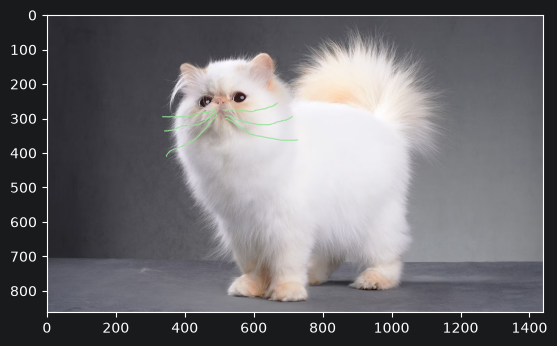

In [8]:
app = DrawingApp(IMG_PATH)
app.run()

modified_img = cv2.imread(app.save_path, cv2.IMREAD_COLOR_RGB)

plt.figure()
plt.imshow(modified_img)